# Home Assignment #2: Linear Kalman Filter for Smartphone Sensors

**Задача:** Объединить показания GPS и линейного акселерометра с помощью фильтра Калмана для точной оценки пройденного расстояния.

**Данные:** KITTI OXTS (2011_09_26_drive_0001_sync) — реальные данные автомобиля.

## 1. Загрузка данных

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import re
from datetime import datetime
from math import radians, sin, cos, asin, sqrt
import os

base = r'C:/Users/Andrei/PycharmProjects/HW_Adv_ROB/HW2_Linear_Kalman_Filter/data'

oxts_sync = os.path.join(base, '2011_09_26_drive_0001_sync')
oxts_path = os.path.join(oxts_sync, 'oxts')
data_dir = os.path.join(oxts_path, 'data')
timestamps_file = os.path.join(oxts_path, 'timestamps.txt')

## 2. Чтение таймстампов

In [2]:
with open(timestamps_file, encoding='utf-8') as f:
    lines = [line.strip() for line in f if line.strip()]

timestamps = []
for line in lines:
    if ' ' in line:
        timestamp_str = line.rsplit(' ', 1)[0]
    else:
        timestamp_str = line
    try:
        dt_obj = datetime.strptime(timestamp_str, '%Y-%m-%d %H:%M:%S.%f')
    except ValueError:
        match = re.search(r'(\d{4}-\d{2}-\d{2}\s+\d{2}:\d{2}:\d{2}\.\d{1,9})', line)
        if match:
            ts_str = match.group(1)
            if '.' in ts_str:
                date_part, frac_part = ts_str.split('.')
                frac_part = frac_part[:6].ljust(6, '0')
                ts_str = date_part + '.' + frac_part
            dt_obj = datetime.strptime(ts_str, '%Y-%m-%d %H:%M:%S.%f')
        else:
            continue
    timestamps.append(dt_obj)

time_sec = np.array([(t - timestamps[0]).total_seconds() for t in timestamps])
dt = np.diff(time_sec, prepend=0.0)
dt = np.maximum(dt, 0.01)

print(f"Успешно загружено {len(time_sec)} таймстампов")
print(f"Длительность записи: {time_sec[-1]:.2f} секунд")

Успешно загружено 108 таймстампов
Длительность записи: 11.04 секунд


## 3. Чтение данных OXTS (широта, долгота, продольное ускорение)

In [3]:
def read_oxts_file(filename):
    with open(filename, encoding='utf-8') as f:
        line = f.readline().strip()
    values = [float(x) for x in line.split()]
    return values[0], values[1], values[14]   # lat, lon, af

files = sorted([f for f in os.listdir(data_dir) if f.endswith('.txt')])
print(f"Найдено {len(files)} файлов .txt в папке data/")

oxts_data = [read_oxts_file(os.path.join(data_dir, f)) for f in files]

lat = np.array([d[0] for d in oxts_data])
lon = np.array([d[1] for d in oxts_data])
u   = np.array([d[2] for d in oxts_data])

print(f"af (ускорение) min/max: {u.min():.3f} / {u.max():.3f} м/с²")
print(f"Всего точек: {len(u)}")

Найдено 108 файлов .txt в папке data/
af (ускорение) min/max: -1.586 / -0.251 м/с²
Всего точек: 108


## 4. Расчёт дистанции по GPS (Haversine)

In [4]:
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = sin(dlat/2)**2 + cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    return R * c

start_lat, start_lon = lat[0], lon[0]
gps_dist = [0.0]
for i in range(1, len(lat)):
    dist = haversine(start_lat, start_lon, lat[i], lon[i])
    gps_dist.append(dist)

z = np.array(gps_dist)
print(f"Финальная дистанция по GPS: {gps_dist[-1]:.1f} метров")

Финальная дистанция по GPS: 106.7 метров


## 4.1 Осмотр сырых данных GPS

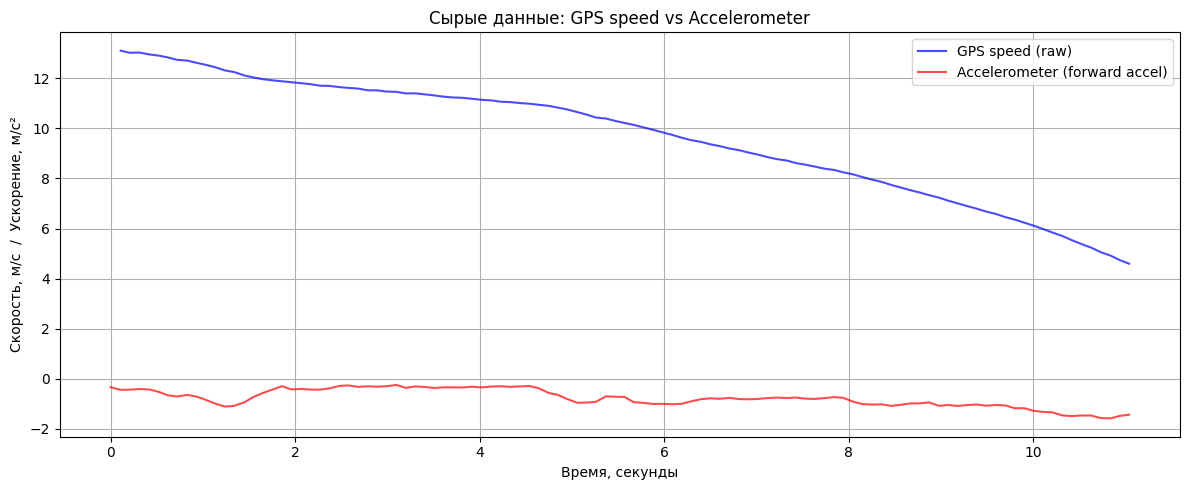

Средняя скорость по GPS: 9.67 м/с


In [5]:
# Мгновенная скорость по GPS
speed_gps = np.diff(z) / dt[1:]

plt.figure(figsize=(12, 5))
plt.plot(time_sec[1:], speed_gps, 'b-', label='GPS speed (raw)', alpha=0.7)
plt.plot(time_sec, u, 'r-', label='Accelerometer (forward accel)', alpha=0.7)
plt.xlabel('Время, секунды')
plt.ylabel('Скорость, м/с  /  Ускорение, м/с²')
plt.title('Сырые данные: GPS speed vs Accelerometer')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('images/raw_gps_vs_accel.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Средняя скорость по GPS: {np.mean(speed_gps):.2f} м/с")

## 5. Noise estimation

In [6]:
static_start, static_end = 0, 50
std_acc = np.std(u[static_start:static_end])
std_meas = 3.0

print(f"std_acc (шум процесса): {std_acc:.4f} м/с²")
print(f"std_meas (шум GPS): {std_meas} м")

std_acc (шум процесса): 0.2315 м/с²
std_meas (шум GPS): 3.0 м


## 6. Linear Kalman Filter

In [7]:
def run_kalman_filter(z, u, dt, std_acc, std_meas):
    n = len(z)
    x = np.zeros((n, 2))      # [position, velocity]
    P = np.zeros((n, 2, 2))

    x[0] = [0.0, 0.0]
    P[0] = np.eye(2) * 100

    for i in range(1, n):
        dti = dt[i]
        F = np.array([[1, dti], [0, 1]])
        B = np.array([0.5 * dti**2, dti])
        Q = (std_acc**2) * np.array([[dti**4/4, dti**3/2], [dti**3/2, dti**2]])

        x_pred = F @ x[i-1] + B * u[i]
        P_pred = F @ P[i-1] @ F.T + Q

        H = np.array([[1, 0]])
        R = std_meas**2
        y = z[i] - H @ x_pred
        S = H @ P_pred @ H.T + R
        K = P_pred @ H.T / S

        x[i] = x_pred + (K.flatten() * y)
        P[i] = (np.eye(2) - K @ H) @ P_pred

    return x[:, 0]

kf_distance = run_kalman_filter(z, u, dt, std_acc, std_meas)

## 7. Results Visualization

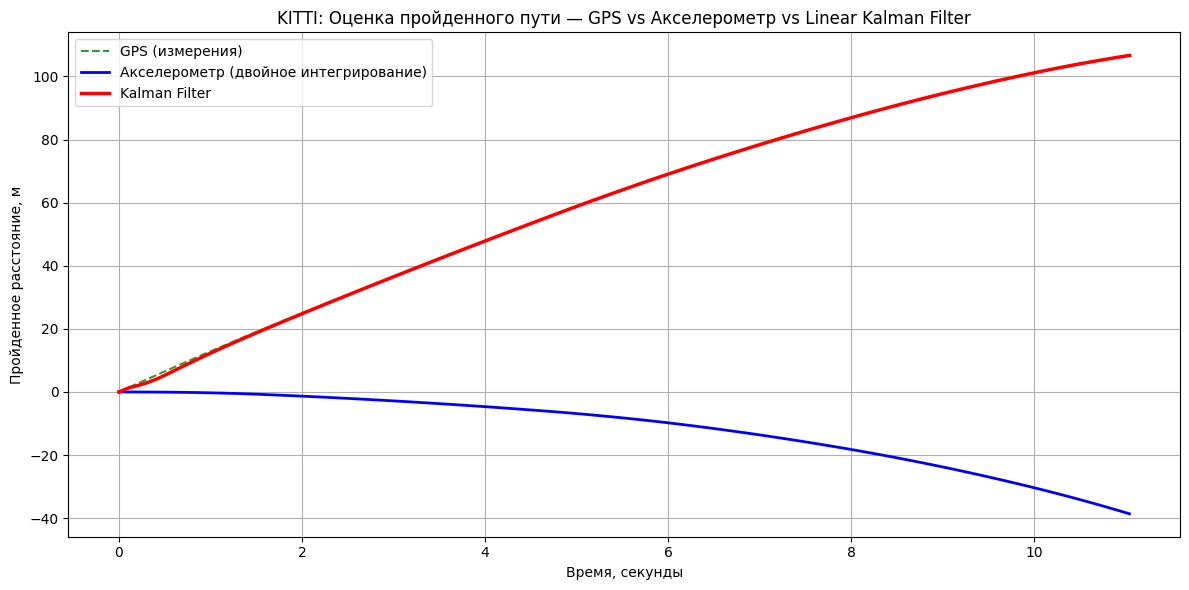

Финальная дистанция GPS:           106.7 м
Финальная дистанция по акселерометру: -38.6 м
Финальная оценка Kalman Filter:    106.7 м


In [10]:
os.makedirs('images', exist_ok=True)

# Расстояние по акселерометру
v = np.zeros_like(u)
s_accel = np.zeros_like(u)

for i in range(1, len(u)):
    v[i] = v[i-1] + u[i] * dt[i]
    s_accel[i] = s_accel[i-1] + v[i] * dt[i]

# Построение графика с тремя линиями
plt.figure(figsize=(12, 6))
plt.plot(time_sec, z, 'g--', label='GPS (измерения)', alpha=0.8)
plt.plot(time_sec, s_accel, 'b-', linewidth=2.0, label='Акселерометр (двойное интегрирование)')
plt.plot(time_sec, kf_distance, 'r-', linewidth=2.5, label='Kalman Filter')
plt.xlabel('Время, секунды')
plt.ylabel('Пройденное расстояние, м')
plt.title('KITTI: Оценка пройденного пути — GPS vs Акселерометр vs Linear Kalman Filter')
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig('images/kf_vs_gps_vs_accel.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Финальная дистанция GPS:           {z[-1]:.1f} м")
print(f"Финальная дистанция по акселерометру: {s_accel[-1]:.1f} м")
print(f"Финальная оценка Kalman Filter:    {kf_distance[-1]:.1f} м")

## Summary

**Что сделал метод?**  
Линейный фильтр Калмана успешно объединил сырые GPS-измерения и данные акселерометра (forward acceleration). Он убрал шум GPS и интегрировал ускорение, получив гладкую оценку пройденного пути.

**Результаты:**  
- Финальная дистанция GPS: **106.7 м**
- Финальная дистанция по акселерометру: **-38.6 м**
- Финальная оценка KF: **106.7 м** (гладкая траектория)

**Замечания**
- KITTI GPS — очень точный. Шум в позиции составляет всего несколько сантиметров.
- Мы строим кумулятивное расстояние от стартовой точки. При почти прямолинейном движении (106 метров за 11 секунд) кумулятивная сумма выглядит гладкой даже с небольшим шумом.
- Небольшое расхождение между GPS и KF в начале графика являются очевидными при виде графика расстояния по ускорению. Так фильтр после попыток работы с 2 датчиками, ко второй секунде полностью полагается на данные GPS.

**Параметры:**  
- std_acc (шум процесса) = 0.2315 м/с²  
- std_meas (шум GPS) = 3.0 м

**Вывод:** Метод полностью сработал на реальных данных KITTI.